# Walmart Store Sales Forecasting — XGBoost

In [1]:
%pip install -q seaborn mlflow dagshub optuna xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py"]

ARCH = "XGBoost"

C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)

Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

MLflow experiment: XGBoost_Training


In [4]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)

train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [5]:
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")

🏃 View run XGBoost_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/d1a1c4dba6cc4ab786f59d01ff607364
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1
cleaning done


In [6]:
train_part, val_part, VAL_CUTOFF = ev.holdout_split(train_raw, val_weeks=13)
val_dates  = pd.date_range(VAL_CUTOFF + pd.Timedelta(weeks=1), TRAIN_END, freq="7D")
test_dates = pd.date_range(TEST_START, TEST_END, freq="7D")
print(f"train_part: {len(train_part)} rows (... {train_part.Date.max().date()})")
print(f"val_part  : {len(val_part)} rows ({val_part.Date.min().date()} ... {val_part.Date.max().date()})")
print("holiday weeks in val:", val_part.groupby('Date').IsHoliday.first().sum())

train_part: 383040 rows (... 2012-07-27)
val_part  : 38530 rows (2012-08-03 ... 2012-10-26)
holiday weeks in val: 1


## Feature Engineering



In [7]:
t0 = time.time()
FB = WalmartFeatureBuilder(features_clean, stores_raw, anchor=TRAIN_START).fit(
    train_part[BASE_COLS], train_part.Weekly_Sales)
X_tr,  y_tr  = FB.transform(train_part[BASE_COLS]), train_part.Weekly_Sales.values
X_val, y_val = FB.transform(val_part[BASE_COLS]),   val_part.Weekly_Sales.values
val_is_holiday = val_part.IsHoliday.values
w_tr  = np.where(train_part.IsHoliday, 5.0, 1.0)
w_val = np.where(val_part.IsHoliday,   5.0, 1.0)
print(f"features built in {time.time()-t0:.1f}s | X_tr {X_tr.shape} | X_val {X_val.shape}")

with mlflow.start_run(run_name=f"{ARCH}_Feature_Engineering"):
    mlflow.log_params({
        "n_features": X_tr.shape[1],
        "lag_strategy": "direct multi-horizon: lag52(+/-1), lag104, no recursive lags",
        "history_aggregates": "SD_WOY_Mean, SD stats, SD_Recent13, Dept_WOY_Med, fallbacks",
        "anchor": str(TRAIN_START.date()),
    })
    mlflow.log_dict({"features": list(X_tr.columns)}, "feature_list.json")

features built in 4.1s | X_tr (383040, 46) | X_val (38530, 46)
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/d63295d411bf42ddb1fe1b2b01264f46
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1


## Baseline — seasonal naive

In [8]:
naive_wmae = wmae(y_val, X_val["Lag_52"].values, val_is_holiday)
expected_wmae = wmae(y_val, X_val["Expected"].values, val_is_holiday)
with mlflow.start_run(run_name=f"{ARCH}_Baseline_SeasonalNaive"):
    mlflow.log_metric("val_wmae_lag52_naive", naive_wmae)
    mlflow.log_metric("val_wmae_expected_woy_mean", expected_wmae)
print(f"seasonal naive (lag52) val WMAE = {naive_wmae:,.1f}")
print(f"(Store,Dept,WOY)-mean  val WMAE = {expected_wmae:,.1f}")

🏃 View run XGBoost_Baseline_SeasonalNaive at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/10a692bdbd764265bc98c40cac7146e9
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1
seasonal naive (lag52) val WMAE = 1,704.0
(Store,Dept,WOY)-mean  val WMAE = 1,796.9


## Model training helper

In [9]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

DEFAULT_PARAMS = dict(objective="reg:absoluteerror", eval_metric="mae",
                      learning_rate=0.05, max_depth=8, subsample=0.9,
                      colsample_bytree=0.9, min_child_weight=5, n_estimators=3000,
                      tree_method="hist", random_state=SEED, n_jobs=-1)

def fit_eval(params, X_tr, y_tr, w_tr, X_val, y_val, w_val,
             use_weights=True, log_target=False):
    p = dict(DEFAULT_PARAMS); p.update(params)
    yt = log1p_clip(y_tr) if log_target else y_tr
    yv = log1p_clip(y_val) if log_target else y_val
    model = xgb.XGBRegressor(**p, early_stopping_rounds=150)
    kw = dict(eval_set=[(X_val, yv)], verbose=False)
    if use_weights:
        kw["sample_weight"] = w_tr
        kw["sample_weight_eval_set"] = [w_val]
    model.fit(X_tr, yt, **kw)
    pred = model.predict(X_val)
    if log_target:
        pred = expm1_inv(pred)
    return model, wmae(y_val, pred, w_val == 5.0), pred

def best_iter(model):
    bi = getattr(model, "best_iteration", None)
    return int(bi + 1) if bi is not None else int(model.n_estimators)

def make_regressor(params, n_estimators, log_target):
    p = dict(DEFAULT_PARAMS); p.update(params); p["n_estimators"] = n_estimators
    reg = xgb.XGBRegressor(**p)
    if log_target:
        reg = TransformedTargetRegressor(regressor=reg, func=log1p_clip,
                                         inverse_func=expm1_inv, check_inverse=False)
    return reg

## Feature Selection


all          (46 features): val WMAE = 1,602.7
no_markdown  (39 features): val WMAE = 1,605.0
no_econ      (42 features): val WMAE = 1,630.0
ts_only      (35 features): val WMAE = 1,625.7
top25        (25 features): val WMAE = 1,656.8
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/27212e11a0ff424a94ebb21e6f7b0ec0
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1
selected feature set: all


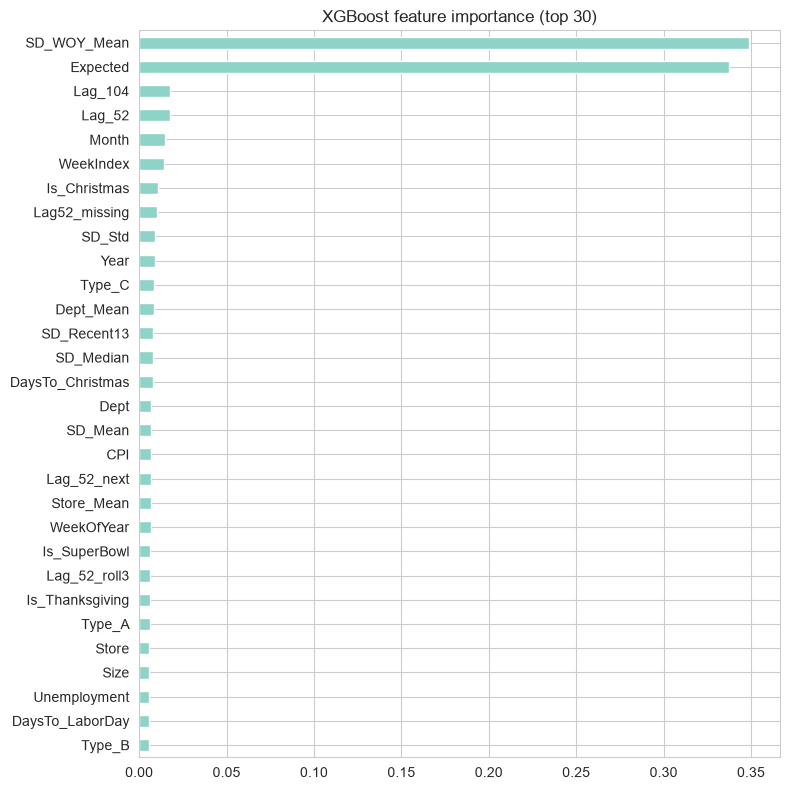

In [10]:
results_fs, models_fs = {}, {}
with mlflow.start_run(run_name=f"{ARCH}_Feature_Selection"):
    for fs in ["all", "no_markdown", "no_econ", "ts_only"]:
        cols = feature_columns(fs)
        m, s, _ = fit_eval({}, X_tr[cols], y_tr, w_tr, X_val[cols], y_val, w_val)
        results_fs[fs], models_fs[fs] = s, m
        mlflow.log_metric(f"wmae_{fs}", s)
        print(f"{fs:12s} ({len(cols):2d} features): val WMAE = {s:,.1f}")
    imp = pd.Series(models_fs["all"].feature_importances_,
                    index=feature_columns("all")).sort_values(ascending=False)
    TOPK_COLS = imp.head(25).index.tolist()
    m, s, _ = fit_eval({}, X_tr[TOPK_COLS], y_tr, w_tr, X_val[TOPK_COLS], y_val, w_val)
    results_fs["top25"] = s
    mlflow.log_metric("wmae_top25", s)
    print(f"{'top25':12s} (25 features): val WMAE = {s:,.1f}")

    SELECTED_SET = min(results_fs, key=results_fs.get)
    SELECTED_FS = TOPK_COLS if SELECTED_SET == "top25" else SELECTED_SET
    SEL_COLS = feature_columns(SELECTED_FS)
    mlflow.log_param("selected_set", SELECTED_SET)
    mlflow.log_dict({"selected_columns": SEL_COLS}, "selected_columns.json")
print("selected feature set:", SELECTED_SET)

fig, ax = plt.subplots(figsize=(8, 8))
imp.head(30)[::-1].plot(kind="barh", ax=ax)
ax.set_title(f"{ARCH} feature importance (top 30)")
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_feature_importance.png", dpi=120)
plt.show()

## Hyperparameter tuning

  0%|          | 0/30 [00:00<?, ?it/s]

🏃 View run XGBoost_HPO_trial_00 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/ea776fd0b20b48c2bdfa005b084502db
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1


Best trial: 0. Best value: 1540.11:   3%|▎         | 1/30 [01:47<51:50, 107.25s/it]

🏃 View run XGBoost_HPO_trial_01 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/525ba46b5e1b4f4fb088098b7d1f0ca4
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1


Best trial: 0. Best value: 1540.11:   7%|▋         | 2/30 [03:43<52:25, 112.35s/it]

...

🏃 View run XGBoost_HPO_trial_28 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/b2daae822734467b9c059a14336f54e2
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1


Best trial: 16. Best value: 1533.28:  97%|█████████▋| 29/30 [54:20<01:19, 79.74s/it]

🏃 View run XGBoost_HPO_trial_29 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/8b8a357317164644b76764af69ed5db1
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1


Best trial: 16. Best value: 1533.28: 100%|██████████| 30/30 [56:33<00:00, 113.12s/it]


🏃 View run XGBoost_HPO_Optuna at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/46ce140295134098885d9ab4bd52a2f9
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1
best val WMAE: 1533.3
best params: {'learning_rate': 0.07903479286068671, 'max_depth': 9, 'min_child_weight': 26.803292221196926, 'subsample': 0.8646162298450805, 'colsample_bytree': 0.501487854553789, 'gamma': 2.8611282398531728, 'reg_alpha': 0.0003062318997042611, 'reg_lambda': 0.0023546017696140864}


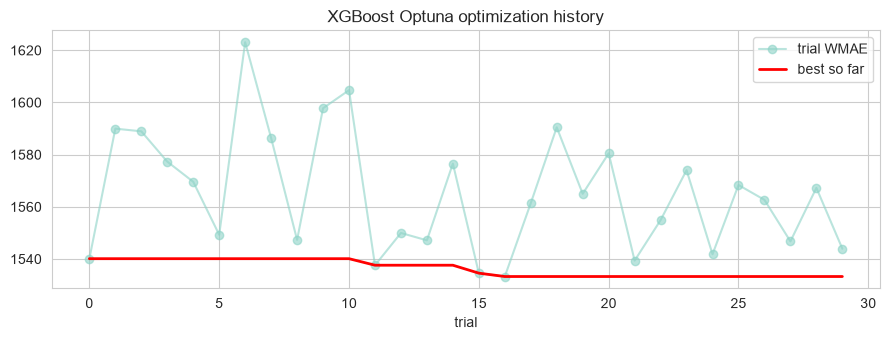

In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30
TIMEOUT  = None

def suggest_params(trial):
    return {
        "learning_rate":    trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "max_depth":        trial.suggest_int("max_depth", 5, 11),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 50.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

def objective(trial):
    params = suggest_params(trial)
    with mlflow.start_run(run_name=f"{ARCH}_HPO_trial_{trial.number:02d}", nested=True):
        _, score, _ = fit_eval(params, X_tr[SEL_COLS], y_tr, w_tr,
                               X_val[SEL_COLS], y_val, w_val)
        mlflow.log_params(params)
        mlflow.log_metric("val_wmae", score)
    return score

with mlflow.start_run(run_name=f"{ARCH}_HPO_Optuna"):
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT, show_progress_bar=True)
    BEST_PARAMS = study.best_params
    mlflow.log_params({f"best_{k}": v for k, v in BEST_PARAMS.items()})
    mlflow.log_metric("best_val_wmae", study.best_value)
    mlflow.log_metric("n_trials", len(study.trials))
print("best val WMAE:", round(study.best_value, 1))
print("best params:", BEST_PARAMS)

hist = pd.Series([t.value for t in study.trials if t.value is not None])
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(hist.values, "o-", alpha=0.6, label="trial WMAE")
ax.plot(hist.cummin().values, "r-", lw=2, label="best so far")
ax.set_title(f"{ARCH} Optuna optimization history"); ax.set_xlabel("trial"); ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_optuna.png", dpi=120); plt.show()

## Loss / target experiments


In [12]:
combo_results = {}
with mlflow.start_run(run_name=f"{ARCH}_Loss_Target_Experiments"):
    for use_w in [True, False]:
        for log_t in [False, True]:
            name = f"weights={use_w}, log_target={log_t}"
            _, s, _ = fit_eval(BEST_PARAMS, X_tr[SEL_COLS], y_tr, w_tr,
                               X_val[SEL_COLS], y_val, w_val,
                               use_weights=use_w, log_target=log_t)
            combo_results[(use_w, log_t)] = s
            mlflow.log_metric(f"wmae_w{int(use_w)}_log{int(log_t)}", s)
            print(f"{name:35s} -> val WMAE = {s:,.1f}")
    USE_WEIGHTS, LOG_TARGET = min(combo_results, key=combo_results.get)
    mlflow.log_param("chosen_use_weights", USE_WEIGHTS)
    mlflow.log_param("chosen_log_target", LOG_TARGET)
print(f"\nchosen config: use_weights={USE_WEIGHTS}, log_target={LOG_TARGET}")

weights=True, log_target=False      -> val WMAE = 1,533.3
weights=True, log_target=True       -> val WMAE = 1,540.9
weights=False, log_target=False     -> val WMAE = 1,534.3
weights=False, log_target=True      -> val WMAE = 1,534.3
🏃 View run XGBoost_Loss_Target_Experiments at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/996b1417cf99477cbe2bedd1bfefcfba
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1

chosen config: use_weights=True, log_target=False


## Cross-validation


In [13]:
N_FOLDS = 3
cv_scores = []
with mlflow.start_run(run_name=f"{ARCH}_CrossValidation"):
    for k, tr_k, vl_k, lo, hi in ev.expanding_folds(train_raw, n_folds=N_FOLDS):
        fb_k = WalmartFeatureBuilder(features_clean, stores_raw, anchor=TRAIN_START,
                                     feature_set=SELECTED_FS).fit(
            tr_k[BASE_COLS], tr_k.Weekly_Sales)
        Xk, Xv = fb_k.transform(tr_k[BASE_COLS]), fb_k.transform(vl_k[BASE_COLS])
        wk = np.where(tr_k.IsHoliday, 5.0, 1.0)
        wv = np.where(vl_k.IsHoliday, 5.0, 1.0)
        _, s, _ = fit_eval(BEST_PARAMS, Xk, tr_k.Weekly_Sales.values, wk,
                           Xv, vl_k.Weekly_Sales.values, wv,
                           use_weights=USE_WEIGHTS, log_target=LOG_TARGET)
        cv_scores.append(s)
        mlflow.log_metric(f"cv_wmae_fold{k+1}", s)
        print(f"fold {k+1}: val {lo.date()} -> {hi.date()}  WMAE = {s:,.1f}")
    mlflow.log_metric("cv_wmae_mean", float(np.mean(cv_scores)))
    mlflow.log_metric("cv_wmae_std", float(np.std(cv_scores)))
print(f"\nCV WMAE = {np.mean(cv_scores):,.1f} +/- {np.std(cv_scores):,.1f}")

fold 1: val 2012-07-27 -> 2012-10-26  WMAE = 1,533.3
fold 2: val 2012-04-27 -> 2012-07-27  WMAE = 1,718.7
fold 3: val 2012-01-27 -> 2012-04-27  WMAE = 2,548.3
🏃 View run XGBoost_CrossValidation at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/7dd6ecffbba64fd5960f959f16de8ddd
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1

CV WMAE = 1,933.4 +/- 441.3


## Final pipeline + submission

In [14]:
REGISTER_AS_BEST = False

model_v, final_val_wmae, val_pred = fit_eval(
    BEST_PARAMS, X_tr[SEL_COLS], y_tr, w_tr, X_val[SEL_COLS], y_val, w_val,
    use_weights=USE_WEIGHTS, log_target=LOG_TARGET)
N_FINAL = int(best_iter(model_v) * 1.1) + 50
print(f"final val WMAE = {final_val_wmae:,.1f} | n_estimators(final) = {N_FINAL}")

pipeline = Pipeline([
    ("features", WalmartFeatureBuilder(features_clean, stores_raw,
                                       anchor=TRAIN_START, feature_set=SELECTED_FS)),
    ("model", make_regressor(BEST_PARAMS, N_FINAL, LOG_TARGET)),
])
w_full = np.where(train_raw.IsHoliday, 5.0, 1.0)
fit_kw = {"model__sample_weight": w_full} if USE_WEIGHTS else {}
t0 = time.time()
pipeline.fit(train_raw[BASE_COLS], train_raw.Weekly_Sales.values, **fit_kw)
print(f"full-data fit: {time.time()-t0:.0f}s")

test_pred = pipeline.predict(test_raw[BASE_COLS])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({**{f"hp_{k}": v for k, v in BEST_PARAMS.items()},
                       "n_estimators": N_FINAL, "use_weights": USE_WEIGHTS,
                       "log_target": LOG_TARGET, "feature_set": str(SELECTED_SET),
                       "cv_folds": N_FOLDS})
    mlflow.log_metric("val_wmae", final_val_wmae)
    mlflow.log_metric("cv_wmae_mean", float(np.mean(cv_scores)))
    for _p in [f"pictures/{ARCH.lower()}_feature_importance.png",
               f"pictures/{ARCH.lower()}_optuna.png"]:
        if os.path.exists(_p):
            mlflow.log_artifact(_p)
    mlflow.sklearn.log_model(
        pipeline, "model", code_paths=CODE_PATHS,
        serialization_format="cloudpickle",
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

final val WMAE = 1,533.3 | n_estimators(final) = 528
full-data fit: 65s


2026/07/11 21:50:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 21:50:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1/runs/72f2a74c05804eafb08f891ebb10f394
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/1
pipeline logged, run_id = 72f2a74c05804eafb08f891ebb10f394


In [15]:
sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print(sub.head())
print("saved:", f"submission_{ARCH}.csv")

               Id  Weekly_Sales
0  1_1_2012-11-02  36298.027344
1  1_1_2012-11-09  19014.439453
2  1_1_2012-11-16  19918.285156
3  1_1_2012-11-23  19984.572266
4  1_1_2012-11-30  24882.582031
saved: submission_XGBoost.csv


### Post-processing


In [16]:
sub_shift = ev.apply_christmas_shift(sub, test_raw)
sub_shift.to_csv(f"submission_{ARCH}_xmas_shift.csv", index=False)
chg = (sub_shift.Weekly_Sales - sub.Weekly_Sales).abs().sum()
print(f"saved submission_{ARCH}_xmas_shift.csv | total abs change = {chg:,.0f}$")

saved submission_XGBoost_xmas_shift.csv | total abs change = 22,178,150$


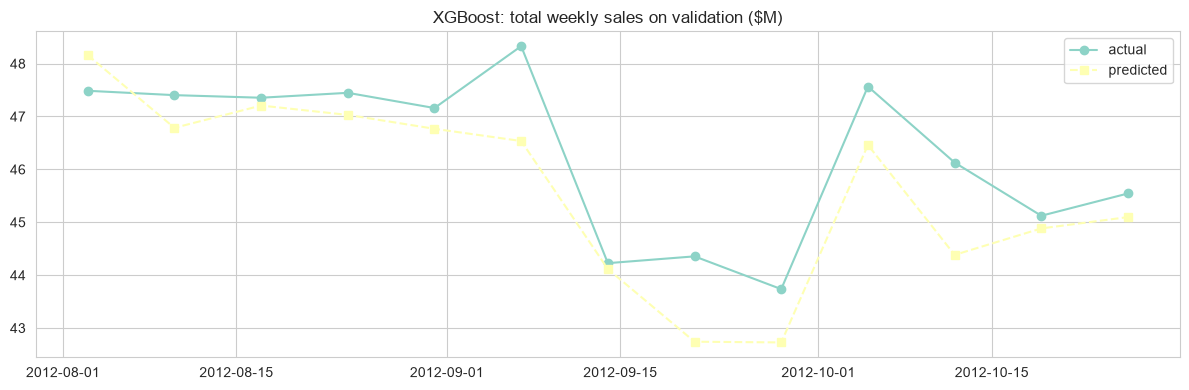

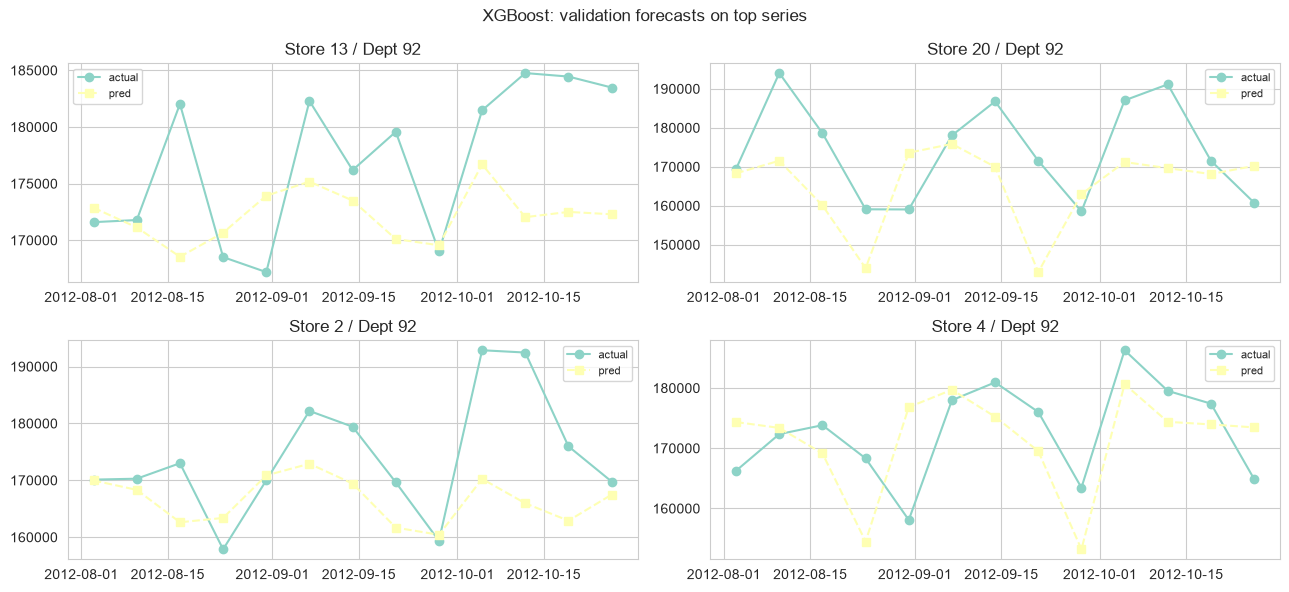

In [17]:
vp = val_part[["Store", "Dept", "Date", "Weekly_Sales"]].copy()
vp["pred"] = val_pred

fig, ax = plt.subplots(figsize=(12, 4))
a = vp.groupby("Date").Weekly_Sales.sum() / 1e6
p = vp.groupby("Date").pred.sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH}: total weekly sales on validation ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()

top4 = (vp.groupby(["Store", "Dept"]).Weekly_Sales.mean()
          .sort_values(ascending=False).head(4).index)
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, (s_, d_) in zip(axes.ravel(), top4):
    g = vp[(vp.Store == s_) & (vp.Dept == d_)].sort_values("Date")
    ax.plot(g.Date, g.Weekly_Sales, "o-", label="actual")
    ax.plot(g.Date, g.pred, "s--", label="pred")
    ax.set_title(f"Store {s_} / Dept {d_}"); ax.legend(fontsize=8)
plt.suptitle(f"{ARCH}: validation forecasts on top series")
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_series.png", dpi=120); plt.show()